Набор данных по цветкам ирисов, или набор данных по ирисам Фишера, — это многомерный набор данных, представленный британским статистиком, евгеником и биологом Рональдом Фишером в его статье 1936 года «Использование множественных измерений в таксономических задачах» в качестве примера линейного дискриминантного анализа. Иногда его называют набором данных по ирисам Андерсона, поскольку Эдгар Андерсон собрал данные для количественной оценки морфологической изменчивости цветков ирисов трёх родственных видов. Два из трёх видов были собраны на полуострове Гаспе «все с одного пастбища, собраны в один и тот же день и измерены в одно и то же время одним и тем же человеком с помощью одного и того же прибора». Статья Фишера была опубликована в журнале Annals of Eugenics, что вызвало споры о дальнейшем использовании набора данных по ирисам для обучения статистическим методам в настоящее время.

Набор данных состоит из 50 образцов каждого из трёх видов ирисов (Iris setosa, Iris virginica и Iris versicolor). Для каждого образца были измерены четыре характеристики: длина и ширина чашелистиков и лепестков в сантиметрах. На основе комбинации этих четырёх характеристик Фишер разработал линейную дискриминантную модель для различения видов.

# Iris Flower Classification

<img src="https://storage.googleapis.com/kaggle-media/learn/images/RcxYYBA.png">

import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler

reading dataset

In [2]:

url="https://raw.githubusercontent.com/nngasu4course/Lab/refs/heads/main/iris.csv"

iris=pd.read_csv(url)

x = iris.iloc[:, [0, 1, 2, 3]].values



In [3]:
iris.info()
iris[0:10]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [4]:
#Frequency distribution of species"
iris_outcome = pd.crosstab(index=iris["species"],  # Make a crosstab
                              columns="count")      # Name the count column

iris_outcome

col_0,count
species,
setosa,50
versicolor,50
virginica,50


In [5]:
iris_setosa=iris.loc[iris["species"]=="Iris-setosa"]
iris_virginica=iris.loc[iris["species"]=="Iris-virginica"]
iris_versicolor=iris.loc[iris["species"]=="Iris-versicolor"]

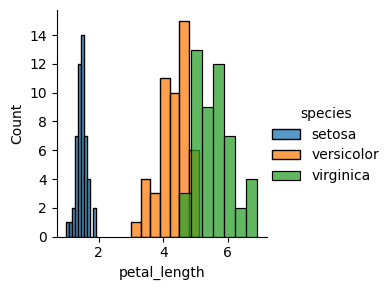

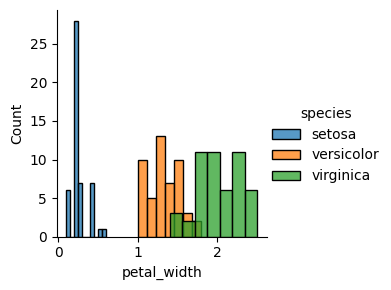

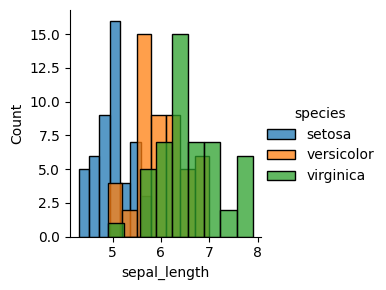

In [6]:



sns.FacetGrid(iris,hue="species").map(sns.histplot,"petal_length").add_legend()
sns.FacetGrid(iris,hue="species").map(sns.histplot,"petal_width").add_legend()
sns.FacetGrid(iris,hue="species").map(sns.histplot,"sepal_length").add_legend()
plt.show()

box plot

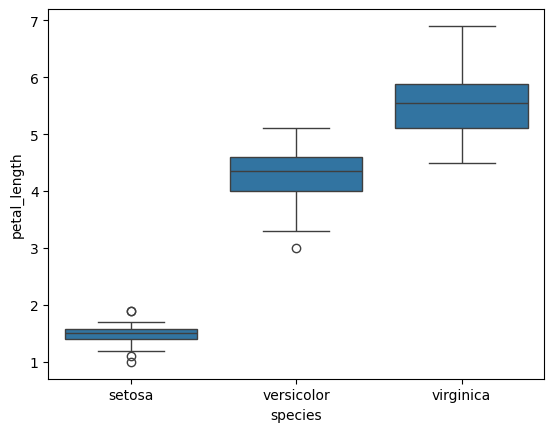

In [7]:
sns.boxplot(x="species",y="petal_length",data=iris)
plt.show()

# **violin plot**

Скрипичный график (violin plot) — это
визуальный способ представления распределения числовых данных, который объединяет в себе ящичную диаграмму (с медианой, квартилями и выбросами) и график плотности распределения. Это позволяет увидеть не только сводную статистику, но и полную форму распределения, включая пики (моды), спады и хвосты данных.
Что означает скрипичный график:
    
*   «Скрипка»: Форма графика напоминает скрипку. Ширина "скрипки" в той или иной точке указывает на плотность распределения данных. Где "скрипка" шире, там больше данных, а где уже, там их меньше.
*   Ящичная диаграмма: Внутри "скрипки" часто есть ящичная диаграмма, которая показывает медиану (центральная линия), квартили (границы "ящика") и иногда точки выбросов.
График плотности: Внешняя форма "скрипки" — это повернутый график плотности распределения (сглаженная гистограмма), который показывает, как часто встречаются значения данных.
*   График плотности: Внешняя форма "скрипки" — это повернутый график плотности распределения (сглаженная гистограмма), который показывает, как часто встречаются значения данных.List item

Сравнение групп: Скрипичные графики особенно полезны для сравнения распределений данных между несколькими группами, поскольку позволяют одновременно визуализировать их пики, спады и хвосты






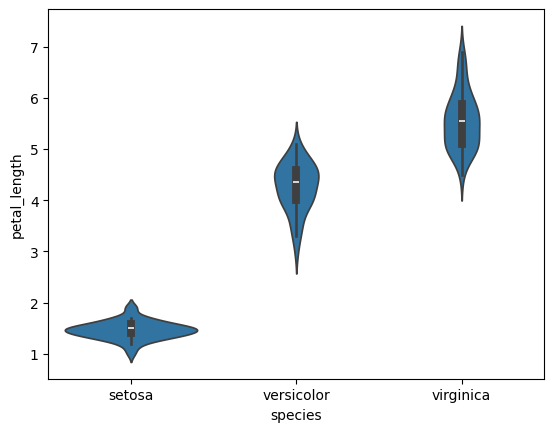

In [8]:
sns.violinplot(x="species",y="petal_length",data=iris)
plt.show()

**Scatter plot**


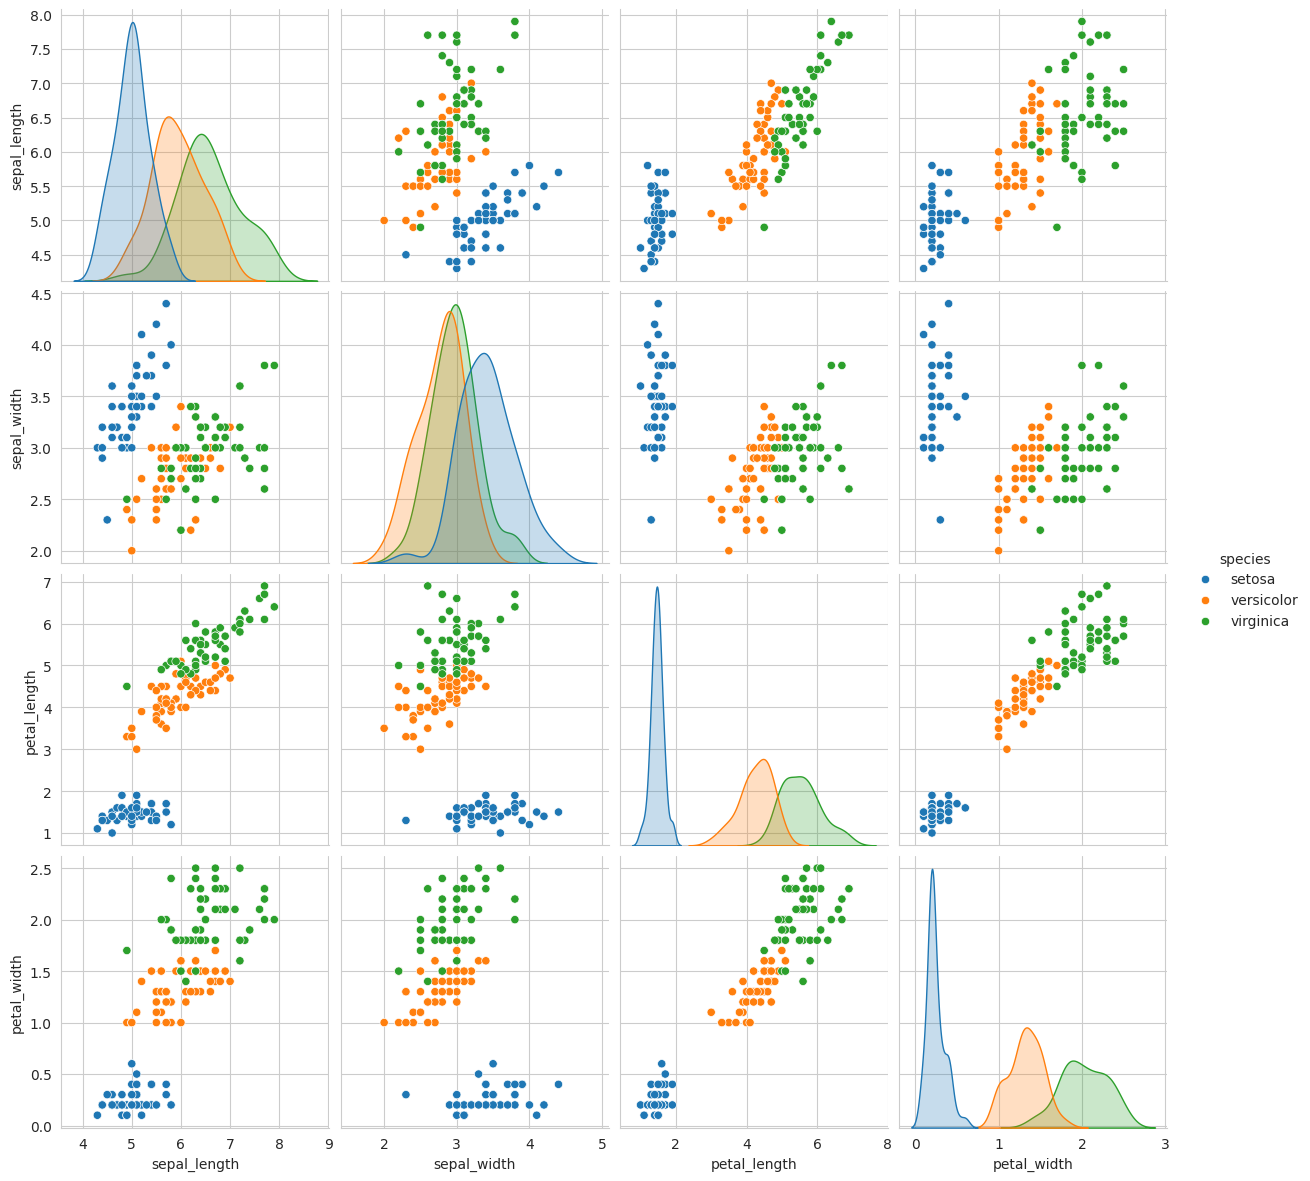

In [9]:
sns.set_style("whitegrid")
sns.pairplot(iris,hue="species",height=3);
plt.show()

# K-Means

Алгоритм K-средних (K-means) — это алгоритм, основанный на центроидах или расстояниях, в котором вычисляются расстояния для присвоения точки кластеру. В алгоритме K-средних каждому кластеру соответствует центроид.

# Как реализовать кластеризацию методом K-средних?

* Выберите количество кластеров k
* Выберите k случайных точек из данных в качестве центроидов
* Присвойте все точки центроидам ближайших кластеров
* Пересчитайте центроиды вновь сформированных кластеров
* Повторите шаги 3 и 4



In [10]:
#Finding the optimum number of clusters for k-means classification
from sklearn.cluster import KMeans
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)

# Использование метода «локтя» для определения оптимального количества кластеров для кластеризации методом k-средних.


Метод «локтя» включает в себя многократное выполнение алгоритма в цикле с увеличением количества кластеров, а затем построение графика оценки кластеризации в зависимости от количества кластеров. Количество кластеров определяется на основе изменения угла на графике.

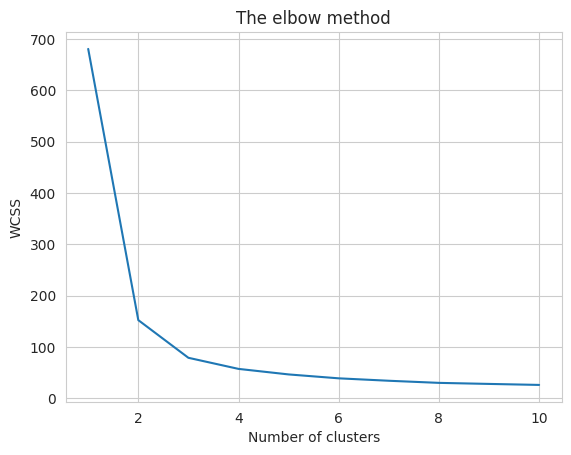

In [11]:
plt.plot(range(1, 11), wcss)
plt.title('The elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS') #within cluster sum of squares
plt.show()

# Implementing K-Means Clustering

In [12]:
kmeans = KMeans(n_clusters = 3, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
y_kmeans = kmeans.fit_predict(x)

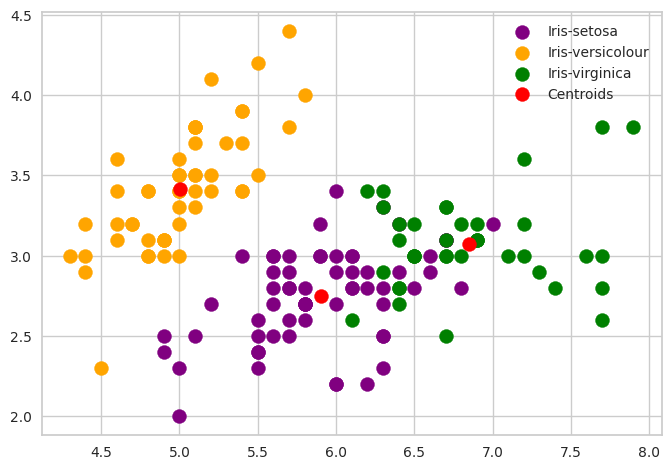

In [ ]:
#Visualising the clusters
plt.scatter(x[y_kmeans == 0, 0], x[y_kmeans == 0, 1], s = 100, c = 'purple', label = 'Iris-setosa')
plt.scatter(x[y_kmeans == 1, 0], x[y_kmeans == 1, 1], s = 100, c = 'orange', label = 'Iris-versicolour')
plt.scatter(x[y_kmeans == 2, 0], x[y_kmeans == 2, 1], s = 100, c = 'green', label = 'Iris-virginica')

#Plotting the centroids of the clusters
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:,1], s = 100, c = 'red', label = 'Centroids')

plt.legend()


Метод «локтя» включает в себя многократное выполнение алгоритма в цикле с увеличением количества кластеров, а затем построение графика оценки кластеризации в зависимости от количества кластеров. Количество кластеров определяется на основе изменения угла на графике.


In [13]:
x = iris.iloc[:, [0, 1, 2, 3]].values
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)

In [14]:
import plotly.express as px

fig = px.line(iris, x=range(1, 11), y=wcss)
fig.show()

In [15]:
kmeans = KMeans(n_clusters = 3, init = 'k-means++',
                max_iter = 300, n_init = 10, random_state = 0)
y_kmeans = kmeans.fit_predict(x)

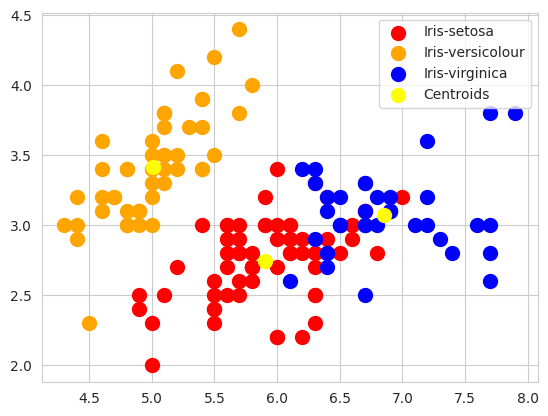

In [16]:
plt.scatter(x[y_kmeans == 0, 0], x[y_kmeans == 0, 1],
            s = 100, c = 'red', label = 'Iris-setosa')
plt.scatter(x[y_kmeans == 1, 0], x[y_kmeans == 1, 1],
            s = 100, c = 'orange', label = 'Iris-versicolour')
plt.scatter(x[y_kmeans == 2, 0], x[y_kmeans == 2, 1],
            s = 100, c = 'blue', label = 'Iris-virginica')

# Plotting the centroids of the clusters
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:,1],
            s = 100, c = 'yellow', label = 'Centroids')

plt.legend()

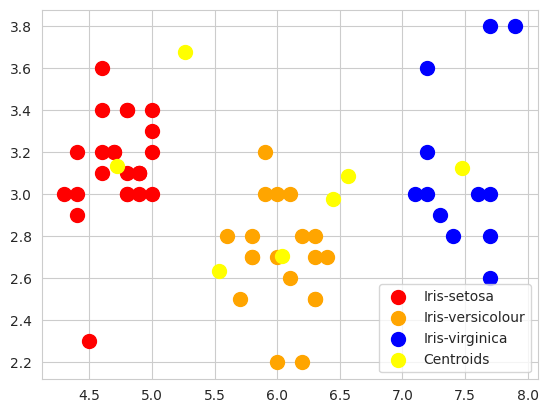

In [17]:
kmeans = KMeans(n_clusters = 7, init = 'k-means++',
                max_iter = 300, n_init = 10, random_state = 0)
y_kmeans = kmeans.fit_predict(x)
plt.scatter(x[y_kmeans == 0, 0], x[y_kmeans == 0, 1],
            s = 100, c = 'red', label = 'Iris-setosa')
plt.scatter(x[y_kmeans == 1, 0], x[y_kmeans == 1, 1],
            s = 100, c = 'orange', label = 'Iris-versicolour')
plt.scatter(x[y_kmeans == 2, 0], x[y_kmeans == 2, 1],
            s = 100, c = 'blue', label = 'Iris-virginica')

# Plotting the centroids of the clusters
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:,1],
            s = 100, c = 'yellow', label = 'Centroids')

plt.legend()

Силуэт кластера — метод графического представления результатов кластеризации, с помощью которого можно визуально оценить качество построенной кластерной модели.

В основе идеи метода лежит вычисление коэффициентов кластерных силуэтов. На диаграмме для каждого объекта коэффициент силуэта отображается прямоугольником соответствующей длины. Прямоугольники группируются по кластерам (которые обычно выделяются цветом) и в каждом кластере дополнительно ранжируются в порядке убывания.
Таким образом, на диаграмме становится виден «силуэт» каждого кластера, откуда и название метода. По форме силуэтов аналитик оперативно может оценить качество кластеризации. Чем форма силуэтов ближе к прямоугольной, а площадь (средний коэффициент силуэта) ближе к 1, тем лучше кластеризация. Внутри силуэта каждого кластера объекты расположены в порядке убывания их коэффициента силуэта, поэтому легко увидеть, какие именно объекты лучше соответствуют кластеру, а какие хуже.

Напротив, чем больше в кластере объектов с низким коэффициентом силуэта, которые порождают «узкие» силуэты, тем хуже кластеризация.

Таким образом, диаграммы силуэтов и средние значения коэффициентов могут использоваться для определения естественного числа кластеров в наборе данных. Поясним сказанное с помощью рисунков.

На следующем рисунке представлено распределение точек данных (слева) в 2-мерном пространстве признаков и диаграмма силуэтов (справа) для случая 2-х кластеров.

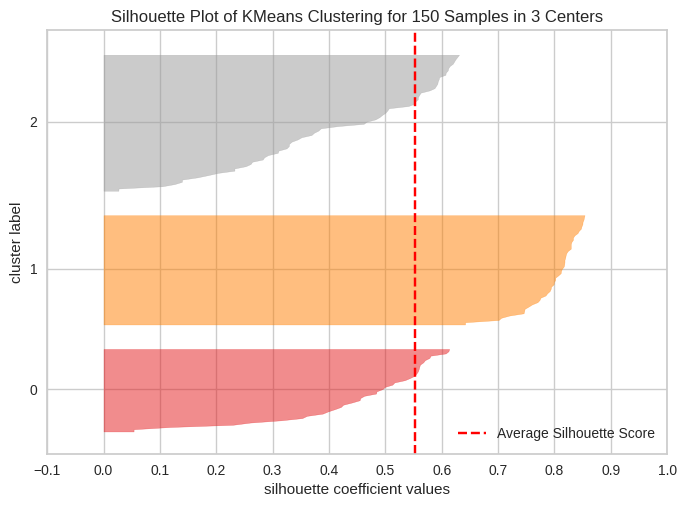

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 150 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [18]:
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
model = KMeans(3)
visualizer = SilhouetteVisualizer(model)

visualizer.fit(x)    # Fit the data to the visualizer
visualizer.show()

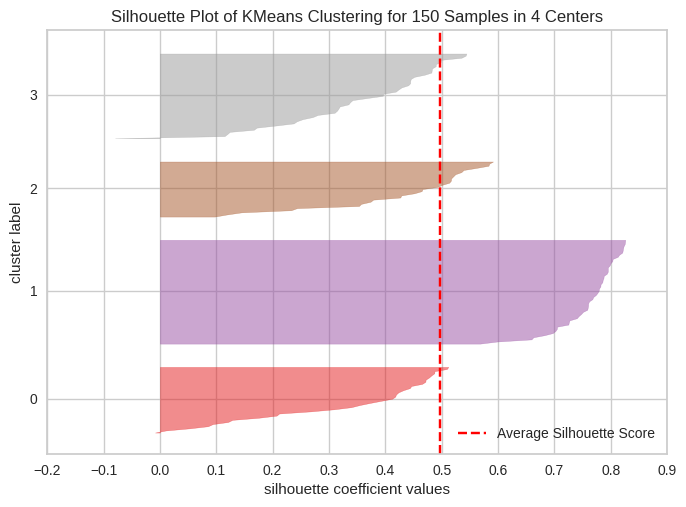

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 150 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [19]:
model = KMeans(4)
visualizer = SilhouetteVisualizer(model)

visualizer.fit(x)    # Fit the data to the visualizer
visualizer.show()



    Оценка силуэта находится в диапазоне [-1, 1].

Оценка силуэта, равная 1, означает, что кластеры очень плотные и хорошо разделены.

Значение 0 означает, что кластеры перекрываются.

Значение меньше 0 означает, что данные, принадлежащие кластерам, могут быть неверными/некорректными.

Толщина графика силуэта, представляющего каждый кластер, также является решающим фактором. Чем равномернее толщина, тем лучше значение K.

Силуэтные графики можно использовать для выбора наиболее оптимального значения K (количества кластеров) в кластеризации методом K-средних.

В приведенных выше примерах мы видим, что при K=3 силуэты близки к 1, имеют одинаковую толщину и больше 0.
